# E9 222 Signal Processing in Practise - Assignment 9
***
*Submitted by: Dwaipayan Haldar*<br>
*S.R. No. : 27128*

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.transform import rotate
import os
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from typing import Callable, Literal
from torch import Tensor
from PIL import Image
from torch.utils.data import Dataset
import torch.nn.functional as F
import json
from resnet9 import *

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


In [4]:

# ─── Configuration & Paths ───────────────────────────────────────────────────
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2023, 0.1994, 0.2010]

DATA_ROOT      = 'cifar10_3class_fixmatch'
LABELED_ROOT   = os.path.join(DATA_ROOT, 'labeled')
UNLABELED_ROOT = os.path.join(DATA_ROOT, 'unlabeled')
VAL_ROOT       = os.path.join(DATA_ROOT, 'val')
TEST_ROOT      = os.path.join(DATA_ROOT, 'test')

NUM_CLASSES = 3
BATCH_SIZE  = 32          # labeled batch size B
MU          = 4           # unlabeled batch multiplier  → unlabeled batch = MU * BATCH_SIZE

print(f"Device : {device}")
print(f"Labeled batch size   B  = {BATCH_SIZE}")
print(f"Unlabeled batch size μB = {MU * BATCH_SIZE}")


Device : mps
Labeled batch size   B  = 32
Unlabeled batch size μB = 128


## Dataset & Augmentations

In [5]:

class UnlabeledDataset(Dataset):
    """Flat-directory dataset for unlabeled images.
    Returns a (weak_aug, strong_aug) pair for each image.
    """
    def __init__(self, root: str, weak_transform, strong_transform):
        self.root = root
        exts = ('.png', '.jpg', '.jpeg')
        self.files = sorted(f for f in os.listdir(root) if f.lower().endswith(exts))
        self.weak_tf   = weak_transform
        self.strong_tf = strong_transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.files[idx])).convert('RGB')
        return self.weak_tf(img), self.strong_tf(img)


# ─── Transforms ──────────────────────────────────────────────────────────────
normalize = transforms.Normalize(mean=MEAN, std=STD)

# No-augmentation transform (val / test)
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    normalize,
])

# Supervised labeled transform (light augmentation)
labeled_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

# FixMatch weak augmentation  (same as labeled)
weak_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    normalize,
])

# FixMatch strong augmentation: RandAugment + RandomErasing (on tensor)
strong_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    normalize,
    transforms.RandomErasing(p=0.5),
])

print("Transforms defined.")


Transforms defined.


In [6]:

# ─── DataLoaders ─────────────────────────────────────────────────────────────
labeled_dataset   = datasets.ImageFolder(LABELED_ROOT, transform=labeled_transform)
val_dataset       = datasets.ImageFolder(VAL_ROOT,     transform=eval_transform)
test_dataset      = datasets.ImageFolder(TEST_ROOT,    transform=eval_transform)
unlabeled_dataset = UnlabeledDataset(UNLABELED_ROOT, weak_transform, strong_transform)

labeled_loader    = DataLoader(labeled_dataset,   batch_size=BATCH_SIZE,        shuffle=True,  num_workers=0, drop_last=True)
val_loader        = DataLoader(val_dataset,        batch_size=256,               shuffle=False, num_workers=0)
test_loader       = DataLoader(test_dataset,       batch_size=256,               shuffle=False, num_workers=0)
unlabeled_loader  = DataLoader(unlabeled_dataset,  batch_size=MU * BATCH_SIZE,   shuffle=True,  num_workers=0, drop_last=True)

CLASS_NAMES = labeled_dataset.classes
print(f"Classes       : {CLASS_NAMES}")
print(f"Labeled       : {len(labeled_dataset):>5}  ({len(labeled_loader)} batches/epoch)")
print(f"Unlabeled     : {len(unlabeled_dataset):>5}  ({len(unlabeled_loader)} batches/epoch)")
print(f"Val           : {len(val_dataset):>5}")
print(f"Test          : {len(test_dataset):>5}")


Classes       : ['cat', 'deer', 'dog']
Labeled       :   300  (9 batches/epoch)
Unlabeled     :  5400  (42 batches/epoch)
Val           :   300
Test          :  3000


In [7]:

# ─── Shared evaluation helper ─────────────────────────────────────────────────
def evaluate(model, loader, device):
    """Returns (accuracy, predictions_list, labels_list)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(y.cpu().tolist())
    acc = accuracy_score(all_labels, all_preds)
    return acc, all_preds, all_labels


---
## Q1 — Supervised Training (labeled data only)

In [8]:

def train_supervised(num_epochs=200, lr=1e-3, weight_decay=1e-4, seed=42):
    """Train ResNet-9 on labeled data only (supervised baseline)."""
    torch.manual_seed(seed)
    model     = ResNet9(num_classes=NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.CrossEntropyLoss()

    history = dict(train_loss=[], train_acc=[], val_acc=[])
    best_val_acc, best_state = 0.0, None

    for epoch in tqdm(range(num_epochs), desc='Supervised Training'):
        model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0

        for x, y in labeled_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss   = criterion(logits, y)
            loss.backward()
            optimizer.step()

            ep_loss    += loss.item()
            ep_correct += (logits.argmax(1) == y).sum().item()
            ep_total   += y.size(0)

        scheduler.step()
        val_acc, _, _ = evaluate(model, val_loader, device)

        history['train_loss'].append(ep_loss / len(labeled_loader))
        history['train_acc'].append(ep_correct / ep_total)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, history


print("Training supervised baseline (Q1)...")
sup_model, sup_history = train_supervised(num_epochs=200)

sup_test_acc, sup_preds, sup_labels = evaluate(sup_model, test_loader, device)
print(f"\n[Q1] Supervised Baseline  — Test Accuracy: {sup_test_acc*100:.2f}%")


Training supervised baseline (Q1)...


Supervised Training:   0%|          | 0/200 [00:00<?, ?it/s]


[Q1] Supervised Baseline  — Test Accuracy: 57.50%


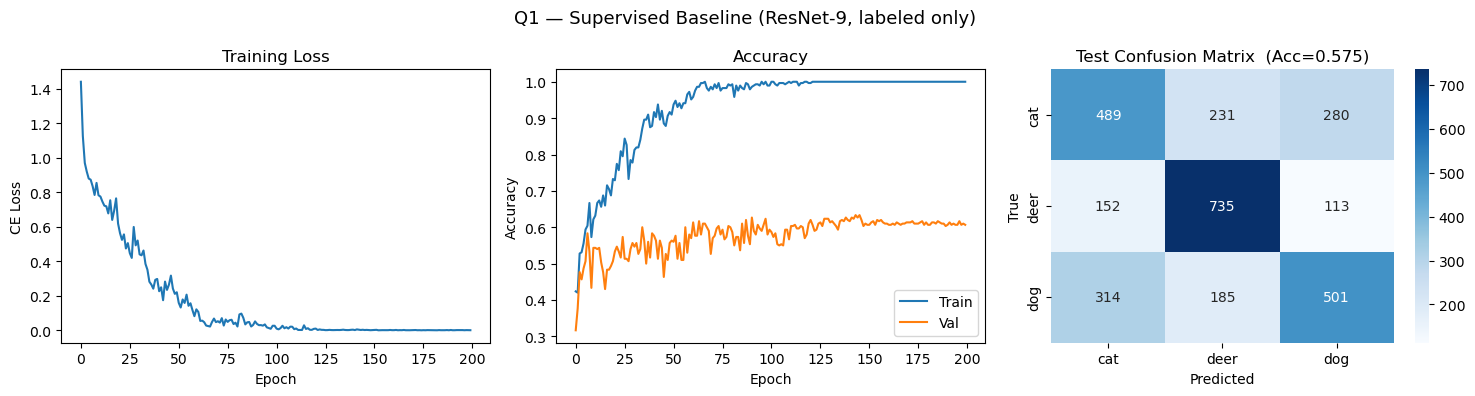

              precision    recall  f1-score   support

         cat       0.51      0.49      0.50      1000
        deer       0.64      0.73      0.68      1000
         dog       0.56      0.50      0.53      1000

    accuracy                           0.57      3000
   macro avg       0.57      0.58      0.57      3000
weighted avg       0.57      0.57      0.57      3000



In [9]:

# ─── Q1 Plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Q1 — Supervised Baseline (ResNet-9, labeled only)', fontsize=13)

axes[0].plot(sup_history['train_loss'])
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss')

axes[1].plot(sup_history['train_acc'], label='Train')
axes[1].plot(sup_history['val_acc'],   label='Val')
axes[1].set_title('Accuracy');  axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

cm_sup = confusion_matrix(sup_labels, sup_preds)
sns.heatmap(cm_sup, annot=True, fmt='d', ax=axes[2],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
axes[2].set_title(f'Test Confusion Matrix  (Acc={sup_test_acc:.3f})')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig('q1_supervised_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(sup_labels, sup_preds, target_names=CLASS_NAMES))


---
## Q2 — FixMatch (semi-supervised)

**Augmentations**
- **Weak**: `RandomHorizontalFlip` + `RandomVerticalFlip`  
- **Strong**: `RandomHorizontalFlip` + `RandomVerticalFlip` + `RandAugment(num_ops=2, magnitude=9)` + `RandomErasing(p=0.5)`

**Algorithm**:  `L = L_s + λ · L_u` , where `L_u` is masked by confidence threshold `τ`.

In [10]:

from itertools import cycle

def fixmatch_epoch(model, labeled_loader, unlabeled_loader,
                   optimizer, threshold: float, lambda_u: float, device):
    """One epoch of FixMatch.

    Iterates over the unlabeled dataset once; cycles labeled data as needed.
    Returns a dict of average scalar metrics.
    """
    model.train()
    labeled_iter = cycle(labeled_loader)
    n = len(unlabeled_loader)

    agg = dict(loss=0., loss_s=0., loss_u=0., mask_ratio=0.)

    for x_weak_u, x_strong_u in unlabeled_loader:
        x_l, y_l = next(labeled_iter)

        x_l       = x_l.to(device);       y_l       = y_l.to(device)
        x_weak_u  = x_weak_u.to(device);  x_strong_u = x_strong_u.to(device)

        # ── Supervised loss ────────────────────────────────────────────────
        loss_s = F.cross_entropy(model(x_l), y_l)

        # ── Pseudo-labels from weak view (no gradient) ─────────────────────
        with torch.no_grad():
            probs_weak   = F.softmax(model(x_weak_u), dim=-1)
            max_probs, pseudo_labels = probs_weak.max(dim=-1)
            mask = (max_probs >= threshold).float()          # shape (µB,)

        # ── Consistency loss on strong view ────────────────────────────────
        logits_strong = model(x_strong_u)
        loss_u = (F.cross_entropy(logits_strong, pseudo_labels, reduction='none') * mask).mean()

        # ── Total loss ──────────────────────────────────────────────────────
        loss = loss_s + lambda_u * loss_u

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        agg['loss']       += loss.item()
        agg['loss_s']     += loss_s.item()
        agg['loss_u']     += loss_u.item()
        agg['mask_ratio'] += mask.mean().item()

    return {k: v / n for k, v in agg.items()}


def run_fixmatch(threshold: float, lambda_u: float,
                 num_epochs: int = 200, lr: float = 1e-3,
                 weight_decay: float = 1e-4, seed: int = 42,
                 verbose: bool = True):
    """Full FixMatch training run. Returns (model, history, best_val_acc)."""
    torch.manual_seed(seed)
    model     = ResNet9(num_classes=NUM_CLASSES).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = dict(loss=[], loss_s=[], loss_u=[], mask_ratio=[], val_acc=[])
    best_val_acc, best_state = 0.0, None

    desc = f'FixMatch τ={threshold} λ={lambda_u}'
    for epoch in tqdm(range(num_epochs), desc=desc, disable=not verbose):
        stats = fixmatch_epoch(model, labeled_loader, unlabeled_loader,
                               optimizer, threshold, lambda_u, device)
        scheduler.step()
        val_acc, _, _ = evaluate(model, val_loader, device)

        for k, v in stats.items():
            history[k].append(v)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, history, best_val_acc

print("FixMatch training helpers defined.")


FixMatch training helpers defined.


### Hyperparameter Sweep  
Grid search over confidence threshold `τ ∈ {0.70, 0.80, 0.90, 0.95}` and unlabeled weight `λ ∈ {0.5, 1.0, 2.0}`.  
Each configuration is trained for **100 epochs** (quick sweep); best config gets a full **200-epoch** run.

In [11]:

THRESHOLDS   = [0.70, 0.80, 0.90, 0.95]
LAMBDAS      = [0.5, 1.0, 2.0]
SWEEP_EPOCHS = 100   # quick sweep

sweep_results = {}   # (tau, lam) → {'best_val_acc': float, 'history': dict}

for tau in THRESHOLDS:
    for lam in LAMBDAS:
        print(f"\n──── τ={tau}  λ={lam} ────")
        _, hist, best_val = run_fixmatch(tau, lam, num_epochs=SWEEP_EPOCHS, verbose=True)
        sweep_results[(tau, lam)] = {'best_val_acc': best_val, 'history': hist}
        print(f"  → best val acc = {best_val*100:.2f}%")

# ── Find best configuration ──────────────────────────────────────────────────
best_key = max(sweep_results, key=lambda k: sweep_results[k]['best_val_acc'])
best_tau, best_lam = best_key
print(f"\n{'='*50}")
print(f" Best config : τ={best_tau},  λ={best_lam}")
print(f" Best val acc: {sweep_results[best_key]['best_val_acc']*100:.2f}%")
print('='*50)



──── τ=0.7  λ=0.5 ────


FixMatch τ=0.7 λ=0.5:   0%|          | 0/100 [00:00<?, ?it/s]

  → best val acc = 70.00%

──── τ=0.7  λ=1.0 ────


FixMatch τ=0.7 λ=1.0:   0%|          | 0/100 [00:00<?, ?it/s]

  → best val acc = 70.67%

──── τ=0.7  λ=2.0 ────


...

  → best val acc = 69.67%

──── τ=0.95  λ=1.0 ────


FixMatch τ=0.95 λ=1.0:   0%|          | 0/100 [00:00<?, ?it/s]

  → best val acc = 71.00%

──── τ=0.95  λ=2.0 ────


FixMatch τ=0.95 λ=2.0:   0%|          | 0/100 [00:00<?, ?it/s]

  → best val acc = 70.33%

 Best config : τ=0.9,  λ=0.5
 Best val acc: 72.00%


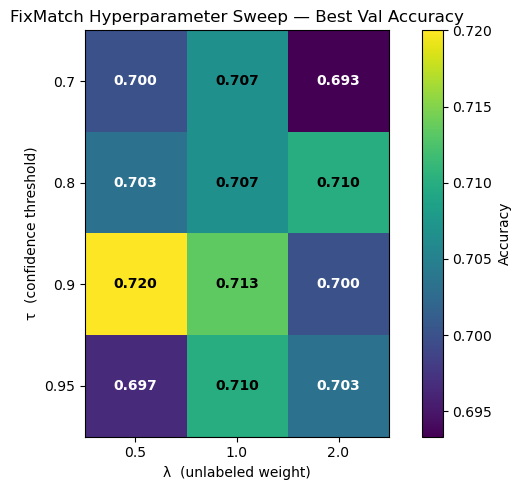

In [20]:

# ─── Heatmap of sweep results ─────────────────────────────────────────────────
tau_list = sorted(set(k[0] for k in sweep_results))
lam_list = sorted(set(k[1] for k in sweep_results))
grid = np.array([[sweep_results[(t, l)]['best_val_acc'] for l in lam_list] for t in tau_list])

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(grid, cmap='viridis', vmin=grid.min(), vmax=grid.max())
ax.set_xticks(range(len(lam_list))); ax.set_xticklabels(lam_list)
ax.set_yticks(range(len(tau_list))); ax.set_yticklabels(tau_list)
ax.set_xlabel('λ  (unlabeled weight)'); ax.set_ylabel('τ  (confidence threshold)')
ax.set_title('FixMatch Hyperparameter Sweep — Best Val Accuracy')
plt.colorbar(im, ax=ax, label='Accuracy')

for i, t in enumerate(tau_list):
    for j, l in enumerate(lam_list):
        color = 'white' if grid[i, j] < grid.mean() else 'black'
        ax.text(j, i, f'{grid[i,j]:.3f}', ha='center', va='center', color=color, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fixmatch_sweep_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:

# ─── Full FixMatch run with best hyperparameters ──────────────────────────────
print(f"Running full FixMatch with τ={best_tau}, λ={best_lam} for 200 epochs ...")
fm_model, fm_history, _ = run_fixmatch(best_tau, best_lam, num_epochs=200, verbose=True)

fm_test_acc, fm_preds, fm_labels = evaluate(fm_model, test_loader, device)
print(f"\n[Q2] FixMatch  (τ={best_tau}, λ={best_lam})  — Test Accuracy: {fm_test_acc*100:.2f}%")


Running full FixMatch with τ=0.9, λ=0.5 for 200 epochs ...


FixMatch τ=0.9 λ=0.5:   0%|          | 0/200 [00:00<?, ?it/s]


[Q2] FixMatch  (τ=0.9, λ=0.5)  — Test Accuracy: 71.37%


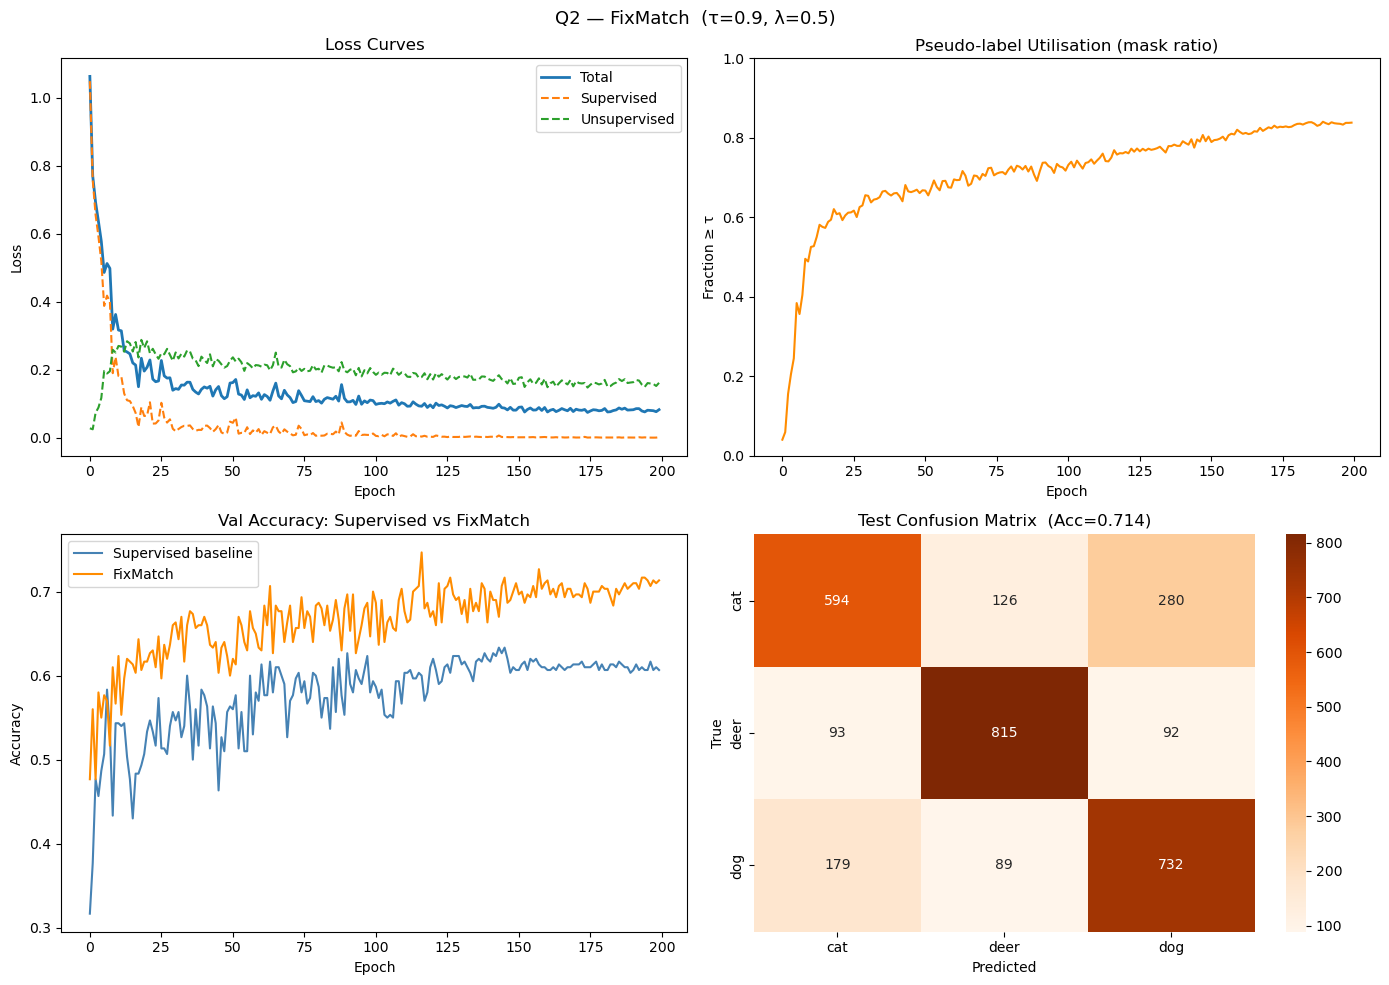

              precision    recall  f1-score   support

         cat       0.69      0.59      0.64      1000
        deer       0.79      0.81      0.80      1000
         dog       0.66      0.73      0.70      1000

    accuracy                           0.71      3000
   macro avg       0.71      0.71      0.71      3000
weighted avg       0.71      0.71      0.71      3000



In [14]:

# ─── Q2 Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Q2 — FixMatch  (τ={best_tau}, λ={best_lam})', fontsize=13)

# Loss curves
axes[0, 0].plot(fm_history['loss'],   label='Total',        linewidth=2)
axes[0, 0].plot(fm_history['loss_s'], label='Supervised',   linestyle='--')
axes[0, 0].plot(fm_history['loss_u'], label='Unsupervised', linestyle='--')
axes[0, 0].set_title('Loss Curves'); axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend()

# Mask ratio (pseudo-label utilisation)
axes[0, 1].plot(fm_history['mask_ratio'], color='darkorange')
axes[0, 1].set_title('Pseudo-label Utilisation (mask ratio)')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Fraction ≥ τ')
axes[0, 1].set_ylim(0, 1)

# Validation accuracy comparison
axes[1, 0].plot(sup_history['val_acc'], label='Supervised baseline', color='steelblue')
axes[1, 0].plot(fm_history['val_acc'],  label='FixMatch',            color='darkorange')
axes[1, 0].set_title('Val Accuracy: Supervised vs FixMatch')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].legend()

# Confusion matrix
cm_fm = confusion_matrix(fm_labels, fm_preds)
sns.heatmap(cm_fm, annot=True, fmt='d', ax=axes[1, 1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Oranges')
axes[1, 1].set_title(f'Test Confusion Matrix  (Acc={fm_test_acc:.3f})')
axes[1, 1].set_xlabel('Predicted'); axes[1, 1].set_ylabel('True')

plt.tight_layout()
plt.savefig('q2_fixmatch_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(fm_labels, fm_preds, target_names=CLASS_NAMES))


In [21]:
#Save sweep results to JSON for future reference
with open('fixmatch_sweep_results.json', 'w') as f:
    json.dump({f"tau={k[0]}_lam={k[1]}": v for k, v in sweep_results.items()}, f, indent=2)

---
## Q3 — Analysis: Supervised Baseline vs FixMatch

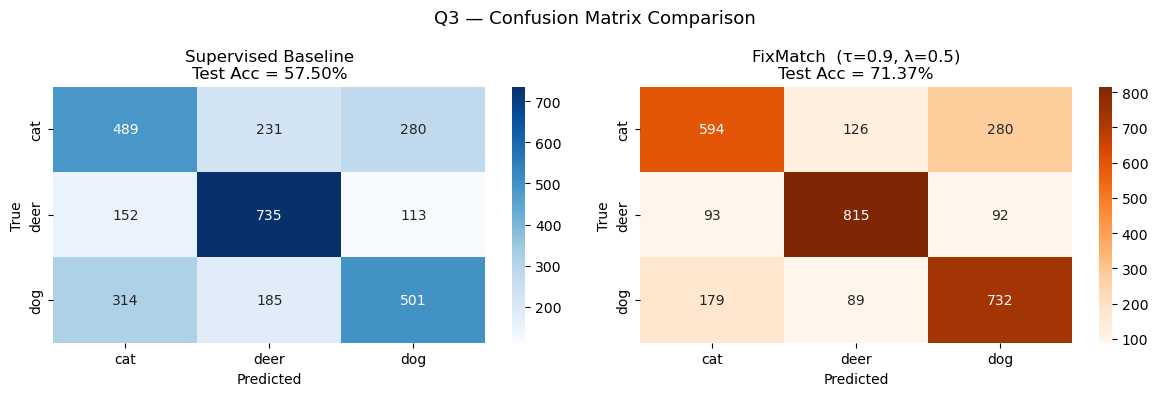

         FINAL RESULTS SUMMARY
  Method                     Test Accuracy
  ─────────────────────────────────────────
  Supervised baseline           57.50%
  FixMatch (τ=0.9, λ=0.5)        71.37%
  ─────────────────────────────────────────
  Improvement                  +13.87%

Per-class accuracy  (test set):

Supervised baseline:
              precision    recall  f1-score   support

         cat     0.5120    0.4890    0.5003      1000
        deer     0.6386    0.7350    0.6834      1000
         dog     0.5604    0.5010    0.5290      1000

    accuracy                         0.5750      3000
   macro avg     0.5703    0.5750    0.5709      3000
weighted avg     0.5703    0.5750    0.5709      3000

FixMatch:
              precision    recall  f1-score   support

         cat     0.6859    0.5940    0.6367      1000
        deer     0.7913    0.8150    0.8030      1000
         dog     0.6630    0.7320    0.6958      1000

    accuracy                         0.7137      3000
  

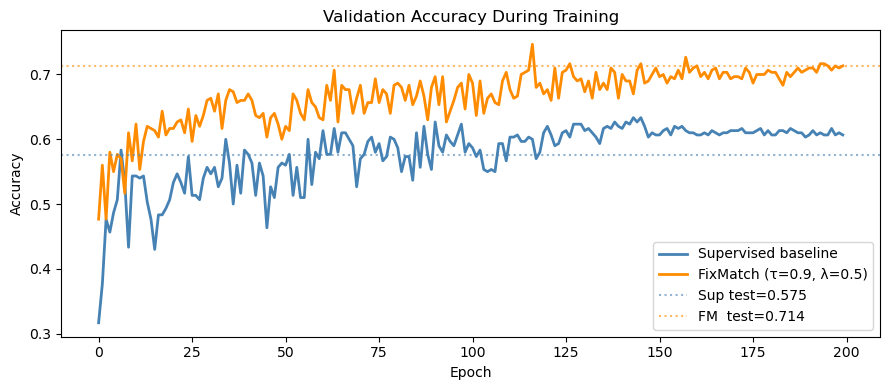


Results saved to fixmatch_results_summary.json


In [15]:

# ─── Side-by-side final comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrices side by side
sns.heatmap(cm_sup, annot=True, fmt='d', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
axes[0].set_title(f'Supervised Baseline\nTest Acc = {sup_test_acc*100:.2f}%')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_fm, annot=True, fmt='d', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Oranges')
axes[1].set_title(f'FixMatch  (τ={best_tau}, λ={best_lam})\nTest Acc = {fm_test_acc*100:.2f}%')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Q3 — Confusion Matrix Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('q3_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Numerical summary table ──────────────────────────────────────────────────
improvement = (fm_test_acc - sup_test_acc) * 100
print("=" * 56)
print("         FINAL RESULTS SUMMARY")
print("=" * 56)
print(f"  Method                     Test Accuracy")
print(f"  ─────────────────────────────────────────")
print(f"  Supervised baseline        {sup_test_acc*100:>8.2f}%")
print(f"  FixMatch (τ={best_tau}, λ={best_lam})     {fm_test_acc*100:>8.2f}%")
print(f"  ─────────────────────────────────────────")
print(f"  Improvement                {improvement:>+8.2f}%")
print("=" * 56)

# ─── Per-class breakdown ──────────────────────────────────────────────────────
print("\nPer-class accuracy  (test set):\n")
from sklearn.metrics import classification_report
print("Supervised baseline:")
print(classification_report(sup_labels, sup_preds, target_names=CLASS_NAMES, digits=4))
print("FixMatch:")
print(classification_report(fm_labels, fm_preds, target_names=CLASS_NAMES, digits=4))

# ─── Val accuracy over epochs ─────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(sup_history['val_acc'], label='Supervised baseline', color='steelblue',  linewidth=2)
plt.plot(fm_history['val_acc'],  label=f'FixMatch (τ={best_tau}, λ={best_lam})', color='darkorange', linewidth=2)
plt.axhline(sup_test_acc, color='steelblue',  linestyle=':', alpha=0.6, label=f'Sup test={sup_test_acc:.3f}')
plt.axhline(fm_test_acc,  color='darkorange', linestyle=':', alpha=0.6, label=f'FM  test={fm_test_acc:.3f}')
plt.title('Validation Accuracy During Training'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('q3_val_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Save all results to JSON for report ──────────────────────────────────────
results_summary = {
    'supervised': {
        'test_accuracy': float(sup_test_acc),
        'best_val_accuracy': float(max(sup_history['val_acc'])),
    },
    'fixmatch': {
        'best_tau': best_tau,
        'best_lam': best_lam,
        'test_accuracy': float(fm_test_acc),
        'best_val_accuracy': float(max(fm_history['val_acc'])),
        'sweep': {str(k): v['best_val_acc'] for k, v in sweep_results.items()},
    },
    'improvement_pct': float(improvement),
}
with open('fixmatch_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("\nResults saved to fixmatch_results_summary.json")
